## Analisis Dataset Bank Marketing

## 1. Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Membaca data
df = pd.read_csv('/content/bank.csv')

In [ ]:
#Menampilkan 5 data pertama
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [ ]:
# Ringkasan data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [ ]:
# Semua sel yang memiliki nilai NaN
df.isna()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
11158,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
11159,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
11160,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
## Mengembalikan jumlah NaN di setiap kolom
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
#Missing value summary
missing_report = pd.DataFrame({
    'Jumlah Missing': df.isna().sum(),
    'Persentase (%)': ((df.isna().sum() / len(df)) * 100).round(0).astype(int)
})
display(missing_report)

,Jumlah Missing,Persentase (%)
age,0,0
job,70,1
marital,0,0
education,497,4
default,0,0
balance,0,0
housing,0,0
loan,0,0
contact,2346,21
day,0,0


In [ ]:
# Menangani Nilai “unknown” → Ubah jadi NaN (biar konsisten)
df = df.replace("unknown", np.nan)
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,<NA>,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,<NA>,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,<NA>,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,<NA>,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,<NA>,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,<NA>,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,<NA>,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,<NA>,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
# Missing Value Berdasarkan Persentasenya
# (A) Kolom missing kecil (<10%) → imputasi MODUS
# (job = 1%, education = 4%)

df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])
df


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,<NA>,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,<NA>,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,<NA>,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,<NA>,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,<NA>,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,<NA>,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,<NA>,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,<NA>,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
# (B) Kolom missing menengah (10–50%) → buat kategori baru
# (contact = 21%)
df['contact'] = df['contact'].fillna('missing')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,<NA>,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,<NA>,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,<NA>,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,<NA>,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,<NA>,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,<NA>,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,<NA>,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,<NA>,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
#(C) Kolom missing besar (75%) → isi dengan kategori ‘unknown’
# (poutcome = 75%)

df['poutcome'] = df['poutcome'].fillna('unknown')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,unknown,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,unknown,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,unknown,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,unknown,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,unknown,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,unknown,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
# Tangani nilai khusus ‘pdays = 999’ → ubah jadi -1 (menandakan belum dihubungi)

df['pdays'] = df['pdays'].replace({999: -1})
df


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,unknown,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,unknown,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,unknown,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,unknown,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,unknown,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,unknown,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
# Cek apakah sudah diganti
df['pdays'].value_counts()


,count
pdays,
-1,8324
92,106
182,89
91,84
181,81
...,...
717,1
159,1
118,1


In [ ]:
# Memperbaiki kolom log transform yang menghasilkan NaN
df['balance_log'] = np.log1p(df['balance'].clip(lower=0))
df['duration_log'] = np.log1p(df['duration'].clip(lower=0))


In [ ]:
# Menampilkan kolom log transform
df[['balance', 'balance_log', 'duration', 'duration_log']].head()


,balance,balance_log,duration,duration_log
0,2343,7.759614,1042,6.949856
1,45,3.828641,1467,7.291656
2,1270,7.147559,1389,7.237059
3,2476,7.814803,579,6.363028
4,184,5.220356,673,6.513230


In [ ]:
# Cek ulang missing value  setelah cleaning
missing_report_after = pd.DataFrame({
    'Missing Setelah Cleaning': df.isna().sum(),
    'Persentase (%)': (df.isna().sum() / len(df) * 100).round(0).astype(int)
})
missing_report_after


,Missing Setelah Cleaning,Persentase (%)
age,0,0
job,0,0
marital,0,0
education,0,0
default,0,0
balance,0,0
housing,0,0
loan,0,0
contact,0,0
day,0,0


In [ ]:
# Cek data duplikat
df.duplicated().sum()


np.int64(0)

In [ ]:
# Cleaning tipe data
categorical_cols = df.select_dtypes(include='object').columns
df[categorical_cols] = df[categorical_cols].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            11162 non-null  int64   
 1   job            11162 non-null  category
 2   marital        11162 non-null  category
 3   education      11162 non-null  category
 4   default        11162 non-null  category
 5   balance        11162 non-null  int64   
 6   housing        11162 non-null  category
 7   loan           11162 non-null  category
 8   contact        11162 non-null  category
 9   day            11162 non-null  int64   
 10  month          11162 non-null  category
 11  campaign       11162 non-null  int64   
 12  pdays          11162 non-null  int64   
 13  previous       11162 non-null  int64   
 14  poutcome       11162 non-null  category
 15  deposit        11162 non-null  category
 16  balance_log    11162 non-null  float64 
 17  duration_log   11162 non-null  

In [ ]:
# Cek Outliers dengan IQR
# Pilih kolom numerik
num_cols = ['age','balance','day','duration','campaign','pdays','previous']

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

# Ambang batas outlier
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Data outlier
outliers = df[((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)]
outliers

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,unknown,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,unknown,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,unknown,yes,7.147559,7.237059
6,56,management,married,tertiary,no,830,yes,yes,missing,6,may,1201,1,-1,0,unknown,yes,6.722630,7.091742
9,28,services,single,secondary,no,5090,yes,no,missing,6,may,1297,3,-1,0,unknown,yes,8.535230,7.168580
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11139,30,self-employed,single,tertiary,no,2593,no,no,missing,27,may,662,7,-1,0,unknown,no,7.860956,6.496775
11140,55,services,divorced,secondary,no,2166,yes,no,missing,28,may,23,17,-1,0,unknown,no,7.681099,3.178054
11145,60,retired,divorced,tertiary,no,-134,no,no,cellular,12,may,243,1,271,4,failure,no,0.000000,5.497168
11155,35,blue-collar,married,secondary,no,80,yes,yes,cellular,21,nov,38,2,172,2,failure,no,4.394449,3.663562


In [ ]:
# Menampilkan jumlah outlier
print("Jumlah outlier:", outliers.shape[0])


Jumlah outlier: 4605


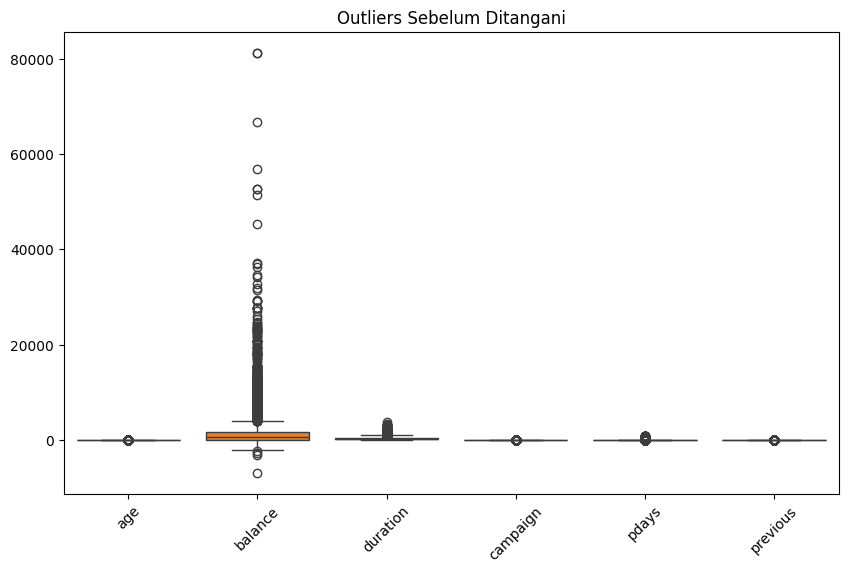

In [ ]:
# Menampilkan outliers sebelum ditangani
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['age','balance','duration','campaign','pdays','previous']])
plt.title("Outliers Sebelum Ditangani")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# Menghapus outlier
df_clean = df[~((df[num_cols] < lower) | (df[num_cols] > upper)).any(axis=1)]
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit,balance_log,duration_log
0,59,admin.,married,secondary,no,2343,yes,no,missing,5,may,1042,1,-1,0,unknown,yes,7.759614,6.949856
1,56,admin.,married,secondary,no,45,no,no,missing,5,may,1467,1,-1,0,unknown,yes,3.828641,7.291656
2,41,technician,married,secondary,no,1270,yes,no,missing,5,may,1389,1,-1,0,unknown,yes,7.147559,7.237059
3,55,services,married,secondary,no,2476,yes,no,missing,5,may,579,1,-1,0,unknown,yes,7.814803,6.363028
4,54,admin.,married,tertiary,no,184,no,no,missing,5,may,673,2,-1,0,unknown,yes,5.220356,6.513230
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no,0.693147,5.552960
11158,39,services,married,secondary,no,733,no,no,missing,16,jun,83,4,-1,0,unknown,no,6.598509,4.430817
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no,3.401197,5.056246
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no,0.000000,2.302585


In [ ]:
print("Jumlah data sebelum:", df.shape[0])
print("Jumlah data setelah:", df_clean.shape[0])
df_clean.describe()


Jumlah data sebelum: 11162
Jumlah data setelah: 6557


,age,balance,day,duration,campaign,pdays,previous,balance_log,duration_log
count,6557.000000,6557.000000,6557.000000,6557.000000,6557.000000,6557.000000,6557.000000,6557.000000,6557.000000
mean,40.218850,756.588989,15.748513,314.693915,2.089523,-0.897514,0.007625,5.124777,5.425533
std,10.757058,986.276392,8.453587,243.149203,1.302275,1.808272,0.111577,2.616255,0.881257
min,18.000000,-2049.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000,1.098612
25%,32.000000,69.000000,8.000000,129.000000,1.000000,-1.000000,0.000000,4.248495,4.867534
50%,38.000000,390.000000,16.000000,237.000000,2.000000,-1.000000,0.000000,5.968708,5.472271
75%,48.000000,1128.000000,22.000000,442.000000,3.000000,-1.000000,0.000000,7.029088,6.093570
max,74.000000,4087.000000,31.000000,1033.000000,6.000000,50.000000,2.000000,8.315811,6.941190


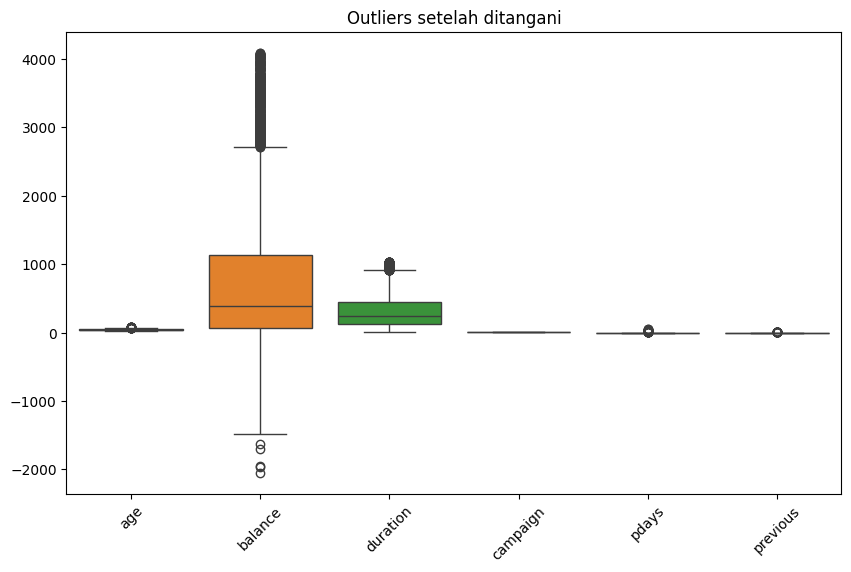

In [ ]:
# Outliers setelah ditangani
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean[['age','balance','duration','campaign','pdays','previous']])
plt.title("Outliers setelah ditangani")
plt.xticks(rotation=45)
plt.show()




Dataset Bank Marketing (UCI) memang terkenal sangat skewed karena alasan berikut:

1. Kolom “balance” sangat tidak merata

Ada nasabah dengan saldo negatif (overdraft) → -3000, -6000

Ada nasabah kaya dengan saldo lebih dari 80.000

Sementara mayoritas nasabah hanya punya saldo 0–2000.
→ Ini menciptakan rentang ekstrem dan outlier besar.

2. Kolom “duration” (durasi panggilan) sangat bervariasi

Ada call 3 detik

Ada call 3881 detik (65 menit)
Call center cenderung punya variasi tinggi → natural outlier.

3. Kolom “campaign” (berapa kali dihubungi) ekstrem

Mayoritas orang dihubungi 1–3 kali

Ada yang dihubungi 63 kali (!!)

Ini sangat tidak wajar dan otomatis dianggap outlier.

4. Kolom “previous”

Banyak nasabah tidak pernah dihubungi sebelumnya, tapi ada yang dihubungi >50 kali dalam campaign sebelumnya.

Jadi…

Outlier di dataset ini bukan karena salah input, tetapi karena real-world data yang memang tidak rata.

## 2. Data Manipulation

In [ ]:
# Handling Data Leakage pada “duration”
df = df.drop(columns=['duration'])


“Duration tidak digunakan dalam modelling karena merupakan post-outcome variable.”

In [ ]:
# Encoding Kategori (sebelum segmentasi)
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded

,age,balance,day,campaign,pdays,previous,balance_log,duration_log,job_enc,marital_enc,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,deposit_yes
0,59,2343,5,1,-1,0,7.759614,6.949856,0,1,...,False,False,True,False,False,False,False,False,True,True
1,56,45,5,1,-1,0,3.828641,7.291656,0,1,...,False,False,True,False,False,False,False,False,True,True
2,41,1270,5,1,-1,0,7.147559,7.237059,9,1,...,False,False,True,False,False,False,False,False,True,True
3,55,2476,5,1,-1,0,7.814803,6.363028,7,1,...,False,False,True,False,False,False,False,False,True,True
4,54,184,5,2,-1,0,5.220356,6.513230,0,1,...,False,False,True,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,1,20,1,-1,0,0.693147,5.552960,1,2,...,False,False,False,False,False,False,False,False,True,False
11158,39,733,16,4,-1,0,6.598509,4.430817,7,1,...,True,False,False,False,False,False,False,False,True,False
11159,32,29,19,2,-1,0,3.401197,5.056246,9,2,...,False,False,False,False,False,False,False,False,True,False
11160,43,0,8,2,172,5,0.000000,2.302585,9,1,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
# Menyamakan huruf
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()


In [ ]:
# Cek apakah sudah berubah
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print(f"\nKolom: {col}")
    print(df[col].unique())



In [ ]:
df.describe()


,age,balance,day,duration,campaign,pdays,previous,balance_log,duration_log
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557,5.617849,5.521881
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007,2.657302,0.955676
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000,0.000000,1.098612
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000,4.812184,4.934474
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000,6.311735,5.545177
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000,7.443664,6.208590
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000,11.304732,8.264106


In [ ]:
df.columns



Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit', 'balance_log', 'duration_log'],
      dtype='object')

In [ ]:
# Membuat Kategori Umur (Youth, Adult, Senior)
df['age_group3'] = pd.cut(
    df['age'],
    bins=[0, 29, 59, 120],
    labels=['youth', 'adult', 'senior']
)
df['age_group3'].value_counts()

,count
age_group3,
adult,8831
youth,1551
senior,780


In [ ]:
 # Membuat Kategori Saldo (Low, Medium, High)
 df['balance_group'] = pd.qcut(
    df['balance'],
    q=3,
    labels=['low', 'medium', 'high']
)
df['balance_group'].value_counts()


,count
balance_group,
low,3724
high,3721
medium,3717


In [ ]:
# Encode Target (deposit → 0/1)
# yes → 1
# no → 0

df['deposit_flag'] = df['deposit'].map({'yes': 1, 'no': 0})

df[['deposit', 'deposit_flag']].head()



,deposit,deposit_flag
0,yes,1
1,yes,1
2,yes,1
3,yes,1
4,yes,1


## EDA

#Keputusan Deposit

/tmp/ipython-input-222484388.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


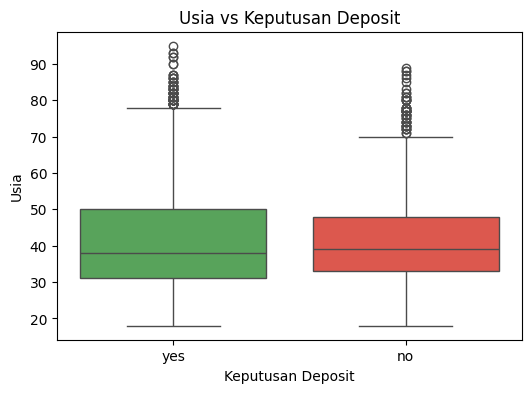

In [ ]:
# Usia Vs Keputusan Deposit

plt.figure(figsize=(6,4))
sns.boxplot(
    x='deposit',
    y='age',
    data=df,
    palette={'yes': '#4CAF50', 'no': '#F44336'}  # hijau = yes, merah = no
)

plt.title('Usia vs Keputusan Deposit')
plt.xlabel('Keputusan Deposit')
plt.ylabel('Usia')
plt.show()


**Insight:**

Nasabah yang membuka deposit cenderung memiliki usia yang lebih matang dibandingkan nasabah yang tidak membuka deposit. Median usia kelompok deposit *yes* sedikit lebih tinggi dan didominasi oleh rentang usia 30–45 tahun. Sebaliknya, nasabah usia lebih muda lebih banyak berada pada kelompok *no*. Hal ini menunjukkan bahwa usia berpengaruh terhadap keputusan pembukaan deposit. Oleh karena itu, segmen usia produktif-menengah merupakan target yang lebih potensial untuk pemasaran produk deposit.


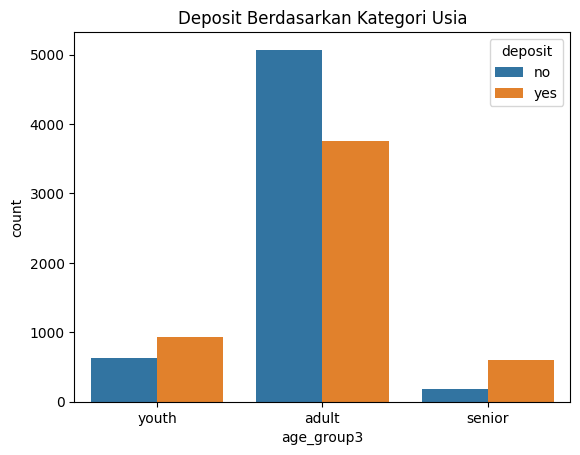

In [ ]:
# Deposit vs Age Group

sns.countplot(data=df, x='age_group3', hue='deposit')
plt.title("Deposit Berdasarkan Kategori Usia")
plt.show()



**Insight**:

Tren menunjukkan usia lebih tua cenderung memiliki saldo lebih besar.

Kelompok adult-senior memiliki posisi paling potensial untuk produk deposit.

membentuk segmen “high-value customers”.


#Kondisi Finansial Nasabah

/tmp/ipython-input-1252451931.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


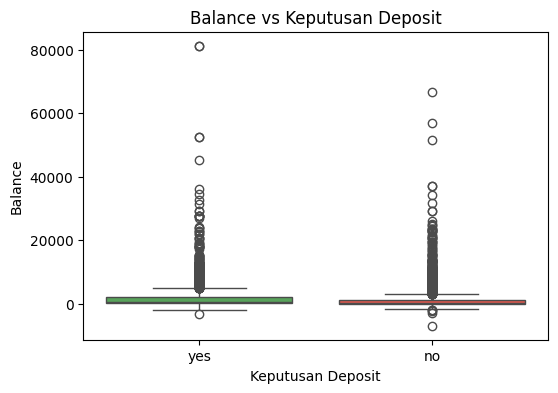

In [ ]:
# Balance vs Deposit

plt.figure(figsize=(6,4))
sns.boxplot(
    x='deposit',
    y='balance',
    data=df,
    palette={'yes': '#4CAF50', 'no': '#F44336'}  # hijau = yes, merah = no
)

plt.title('Balance vs Keputusan Deposit')
plt.xlabel('Keputusan Deposit')
plt.ylabel('Balance')
plt.show()


**Insight:**

Nasabah yang membuka deposit memiliki median saldo yang sedikit lebih tinggi dibandingkan nasabah yang tidak membuka deposit. Namun, distribusi saldo pada kedua kelompok sangat menyebar dan banyak terdapat outlier, terutama pada saldo tinggi. Hal ini menunjukkan bahwa saldo bukan satu-satunya faktor penentu keputusan deposit. Keputusan pembukaan deposit kemungkinan dipengaruhi oleh kombinasi faktor lain seperti usia, pekerjaan, dan strategi kampanye.


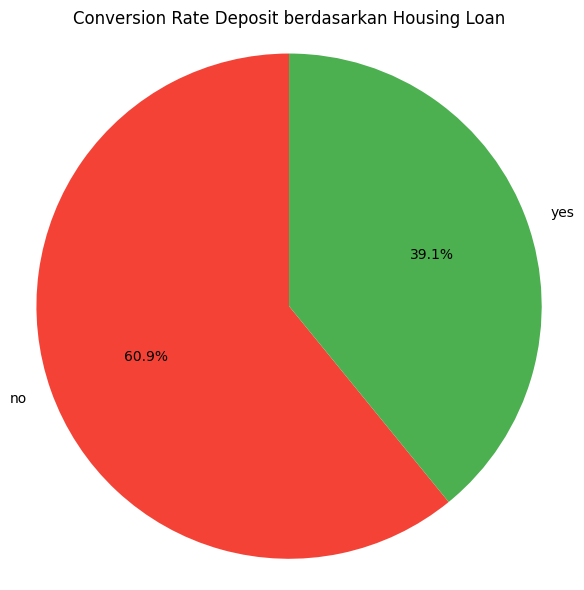

In [3]:
# Menghitung conversion rate deposit berdasarkan housing loan
conversion_housing = (
    df.groupby('housing')['deposit']
      .apply(lambda x: (x == 'yes').mean())
)

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    conversion_housing,
    labels=conversion_housing.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#F44336', '#4CAF50']  # no = merah, yes = hijau
)

plt.title('Conversion Rate Deposit berdasarkan Housing Loan')
plt.axis('equal')  # supaya pie bulat sempurna
plt.tight_layout()
plt.show()



**Insight**:

Berdasarkan perhitungan conversion rate dari data, kelompok nasabah tanpa housing loan menunjukkan proporsi pembukaan deposit yang lebih tinggi dibandingkan kelompok dengan housing loan.

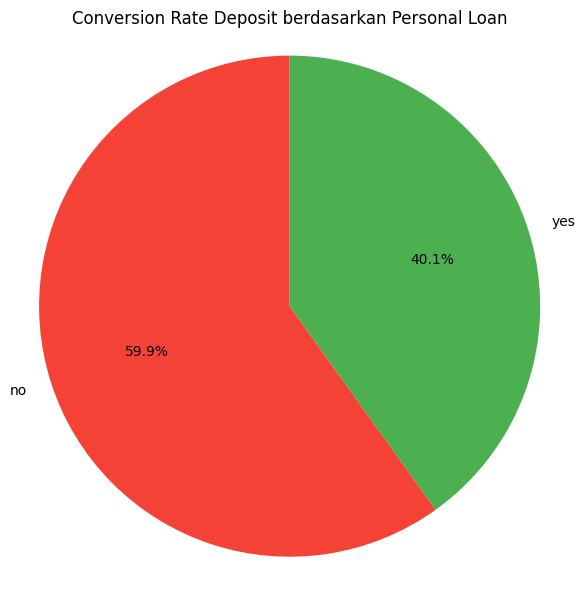

In [4]:
# Personal Loan
# Menghitung conversion rate deposit (yes) berdasarkan personal loan
conversion_loan = (
    df.groupby('loan')['deposit']
      .apply(lambda x: (x == 'yes').mean())
)

# Plot pie chart
plt.figure(figsize=(6,6))
plt.pie(
    conversion_loan,
    labels=conversion_loan.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#F44336', '#4CAF50']  # no = merah, yes = hijau
)

plt.title('Conversion Rate Deposit berdasarkan Personal Loan')
plt.axis('equal')  # supaya pie bulat sempurna
plt.tight_layout()
plt.show()


**Insight**:

Berdasarkan perhitungan conversion rate dari data, nasabah yang tidak memiliki personal loan menunjukkan proporsi pembukaan deposit yang lebih tinggi dibandingkan nasabah yang memiliki personal loan. Hal ini mengindikasikan bahwa beban cicilan personal loan dapat memengaruhi kemampuan dan minat nasabah dalam membuka produk deposit.

#Karakteristik Sosial Nasabah

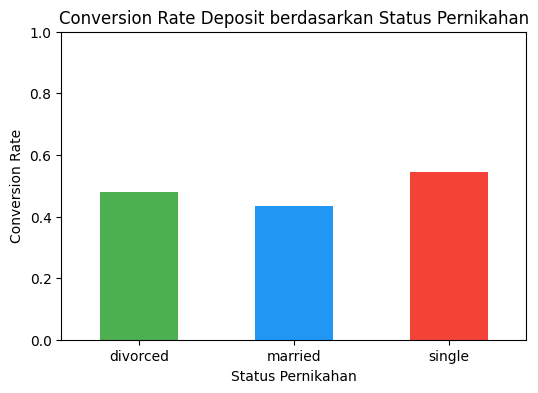

In [ ]:
# Conversion Rate Deposit berdasarkan Status Pernikahan

# Menghitung conversion rate (persentase nasabah yang berhasil melakukan tindakan yang diinginkan)
conversion_marital = (
    df.groupby('marital')['deposit']
      .apply(lambda x: (x == 'yes').mean())
)

# plot
plt.figure(figsize=(6,4))
conversion_marital.plot(
    kind='bar',
    color=['#4CAF50', '#2196F3', '#F44336']
)

plt.title('Conversion Rate Deposit berdasarkan Status Pernikahan')
plt.xlabel('Status Pernikahan')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1)

plt.xticks(rotation=0, ha='center')
plt.yticks(rotation=0)

plt.show()


**Insight:**

Tingkat pembukaan deposit berbeda berdasarkan status pernikahan. Nasabah dengan status single memiliki conversion rate tertinggi, diikuti oleh divorced, sedangkan married memiliki conversion rate terendah. Hal ini menunjukkan bahwa status pernikahan memengaruhi keputusan pembukaan deposit. Strategi pemasaran dapat disesuaikan dengan karakteristik finansial masing-masing kelompok status pernikahan

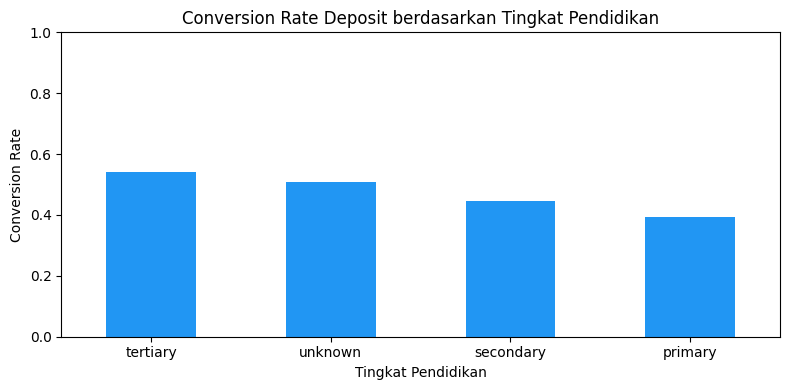

In [ ]:
# Conversion Rate Deposit berdasarkan Pendidikan

# Menghitung conversion rate deposit (yes) per tingkat pendidikan
conversion_education = (
    df.groupby('education')['deposit']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values(ascending=False)
)

# Plot bar chart
plt.figure(figsize=(8,4))
conversion_education.plot(
    kind='bar',
    color='#2196F3'
)

plt.title('Conversion Rate Deposit berdasarkan Tingkat Pendidikan')
plt.xlabel('Tingkat Pendidikan')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Insight**:

Hasil analisis menunjukkan bahwa nasabah dengan tingkat pendidikan tertiary memiliki conversion rate pembukaan deposit tertinggi di antara kategori pendidikan yang terdefinisi. Meskipun kategori unknown juga menunjukkan conversion rate yang relatif tinggi, kategori ini tidak dijadikan dasar kesimpulan karena tidak merepresentasikan tingkat pendidikan yang jelas. Oleh karena itu, tingkat pendidikan tertiary dapat diidentifikasi sebagai salah satu karakteristik utama nasabah yang berpotensi membuka deposit.

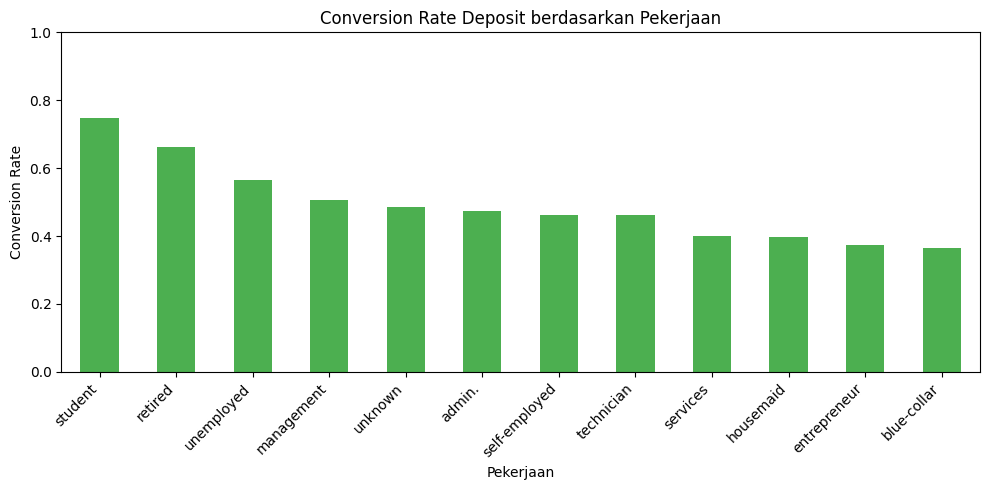

In [ ]:
# Conversion Rate Deposit berdasarkan Pekerjaan

# Hitung conversion rate deposit (yes) per pekerjaan
conversion_job = (
    df.groupby('job')['deposit']
      .apply(lambda x: (x == 'yes').mean())
      .sort_values(ascending=False)
)

# Plot bar chart
plt.figure(figsize=(10,5))
conversion_job.plot(
    kind='bar',
    color='#4CAF50'
)

plt.title('Conversion Rate Deposit berdasarkan Pekerjaan')
plt.xlabel('Pekerjaan')
plt.ylabel('Conversion Rate')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()




**Insight:**

Conversion rate pembukaan deposit paling tinggi terdapat pada nasabah dengan pekerjaan student dan retired. Hal ini menunjukkan bahwa meskipun jumlahnya tidak dominan, kedua kelompok tersebut memiliki kecenderungan lebih besar untuk membuka deposit. Sebaliknya, pekerjaan seperti blue-collar dan entrepreneur memiliki conversion rate yang lebih rendah. Oleh karena itu, jenis pekerjaan merupakan faktor penting dalam menentukan segmentasi nasabah potensial untuk produk deposit.

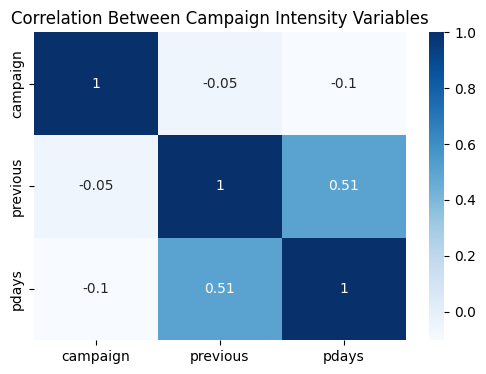

In [ ]:
# Gambaran Umum Intensitas Kampanye
plt.figure(figsize=(6,4))
sns.heatmap(df[['campaign','previous','pdays']].corr(), annot=True, cmap="Blues")
plt.title("Correlation Between Campaign Intensity Variables")
plt.show()




**Insight:**

Heatmap menunjukkan bahwa tidak ada korelasi signifikan antara ketiga variabel:

Campaign vs Previous → sangat rendah

Campaign vs Pdays → hampir nol

Previous vs Pdays → rendah

Hal ini menunjukkan bahwa setiap variabel kampanye berdiri sendiri, sehingga ketiganya sangat layak digunakan dalam segmentasi karena mewakili dimensi perilaku pelanggan yang berbeda
(intensitas kontak saat ini, riwayat kontak sebelumnya, dan jeda waktu sejak terakhir dihubungi).


/tmp/ipython-input-4148361849.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ces_segmen = df.groupby(['campaign_seg','previous_seg'])['CES'].mean()


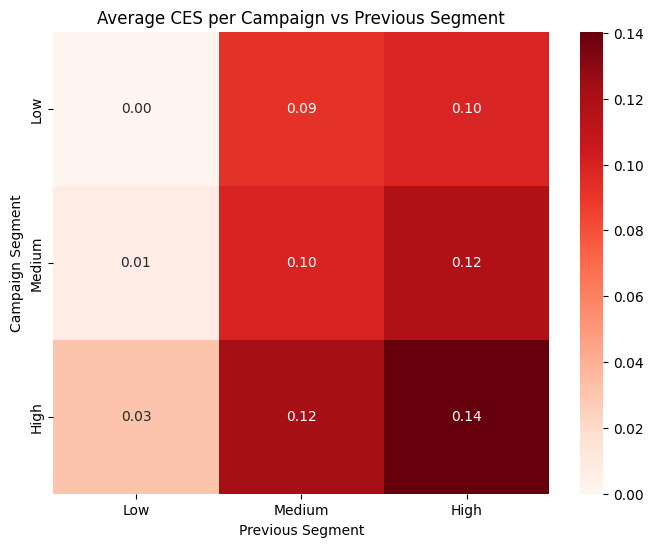

In [ ]:
# Campaign Effectiveness Score (CES)

# Pastikan kolom numerik
df['campaign'] = pd.to_numeric(df['campaign'], errors='coerce')
df['previous'] = pd.to_numeric(df['previous'], errors='coerce')
df['pdays'] = pd.to_numeric(df['pdays'], errors='coerce')

# Drop baris dengan NaN
df = df.dropna(subset=['campaign','previous','pdays'])

# Buat kolom response biner (1=yes, 0=no)
df['response'] = df['deposit'].apply(lambda x: 1 if x.lower() == 'yes' else 0)

# Scaling campaign, previous, pdays agar 0-1
scaler = MinMaxScaler()
df[['campaign_scaled','previous_scaled','pdays_scaled']] = scaler.fit_transform(df[['campaign','previous','pdays']])

# Hitung CES sebagai rata-rata dari ketiga skala
df['CES'] = df[['campaign_scaled','previous_scaled','pdays_scaled']].mean(axis=1)

# Segmentasi campaign dan previous (untuk heatmap)
df['campaign_seg'] = pd.cut(df['campaign'], bins=[-1,1,3,df['campaign'].max()], labels=['Low','Medium','High'])
df['previous_seg'] = pd.cut(df['previous'], bins=[-1,0,2,df['previous'].max()], labels=['Low','Medium','High'])

# Hitung rata-rata CES per segmen
ces_segmen = df.groupby(['campaign_seg','previous_seg'])['CES'].mean()

# Pivot table untuk heatmap
heatmap_data = ces_segmen.unstack()

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="Reds")
plt.title("Average CES per Campaign vs Previous Segment")
plt.ylabel("Campaign Segment")
plt.xlabel("Previous Segment")
plt.show()


**Insight**:

Berdasarkan heatmap CES, kombinasi Campaign High dan Previous Segment High memiliki skor tertinggi (≈0,14) yang menunjukkan kampanye paling efektif dalam menghasilkan konversi. Sebaliknya, pada Previous Segment Low, meskipun intensitas kampanye meningkat, skor CES tetap rendah (≤0,03) sehingga efektivitasnya terbatas. Hal ini menunjukkan bahwa frekuensi kampanye saja tidak cukup tanpa kualitas segmen yang tepat. Dengan demikian, CES memperkuat temuan heatmap dengan menegaskan bahwa kampanye paling efektif terjadi ketika intensitas dan kualitas segmen berjalan selaras.**


**Kesimpulan**

Hasil eksplorasi data menunjukkan bahwa keputusan pembukaan deposit dipengaruhi oleh kombinasi faktor demografis, kondisi finansial, dan karakteristik pekerjaan. Nasabah dengan kondisi finansial yang lebih stabil serta latar belakang pendidikan dan pekerjaan tertentu menunjukkan tingkat konversi yang lebih tinggi. Oleh karena itu, strategi pemasaran yang terarah dan berbasis segmentasi berpotensi meningkatkan efektivitas kampanye deposit.

**Rekomendasi**

Fokuskan pemasaran pada nasabah usia dewasa–menjelang pensiun dengan kondisi finansial stabil

Prioritaskan segmen berpendidikan tertiary serta pekerjaan dengan potensi konversi tinggi

Targetkan nasabah tanpa housing loan dan personal loan

Optimalkan kampanye melalui segmentasi yang lebih tepat dan pengurangan frekuensi kontak berulang



In [ ]:
# Download data dalam bentuk Excel
df.to_excel('BankMarketingFINPRO.xlsx', index=False)